In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import load_model
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

In [11]:
cat4 = cv2.imread('CATS_DOGS/CATS_DOGS/train/CAT/4.jpg')

In [12]:
cat4 = cv2.cvtColor(cat4, cv2.COLOR_BGR2RGB)

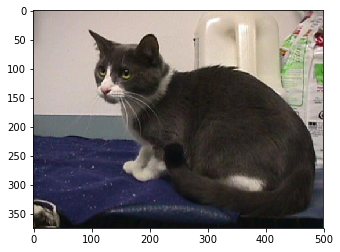

In [13]:
plt.imshow(cat4)

In [14]:
cat4.shape

(375, 500, 3)

In [15]:
dog = cv2.imread('CATS_DOGS/CATS_DOGS/train/DOG/2.jpg')

In [16]:
dog = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

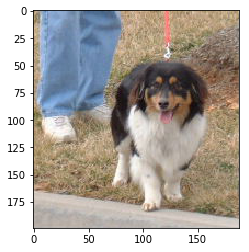

In [17]:
plt.imshow(dog)

In [18]:
dog.shape

(199, 188, 3)

In [19]:
from keras.preprocessing.image import ImageDataGenerator

In [20]:
image_gen = ImageDataGenerator(rotation_range = 30,
                               width_shift_range = 0.1,
                               height_shift_range = 0.1,
                               rescale = 1 / 255,
                               shear_range = 0.2,
                               zoom_range = 0.2,
                               horizontal_flip = True,
                               fill_mode = 'nearest'
                              )

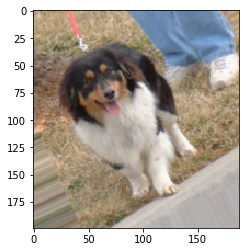

In [21]:
plt.imshow(image_gen.random_transform(dog))

In [22]:
image_gen.flow_from_directory('CATS_DOGS/CATS_DOGS/train')

Found 18743 images belonging to 2 classes.


In [23]:
from keras.models import Sequential
from keras.layers import Activation, Dropout

In [24]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3, 3), input_shape = (150, 150, 3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2)))

model.add(Conv2D(filters = 64, kernel_size = (3, 3), input_shape = (150, 150, 3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2)))

model.add(Conv2D(filters = 64, kernel_size = (3, 3), input_shape = (150, 150, 3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2)))

model.add(Flatten())

model.add(Dense(128))
model.add(Activation('relu'))

model.add(Dropout(0.5))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [29]:
input_shape = (150, 150, 3)

In [25]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 34, 34, 64)        36928     
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 17, 17, 64)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 18496)             0         
__________

In [30]:
batch_size = 16

train_image_gen = image_gen.flow_from_directory('CATS_DOGS/CATS_DOGS/train',
                                                target_size = input_shape[:2],
                                                batch_size = batch_size,
                                                class_mode = 'binary')

Found 18743 images belonging to 2 classes.


In [31]:
test_image_gen = image_gen.flow_from_directory('CATS_DOGS/CATS_DOGS/test',
                                                target_size = input_shape[:2],
                                                batch_size = batch_size,
                                                class_mode = 'binary')

Found 6251 images belonging to 2 classes.


In [32]:
train_image_gen.class_indices

{'CAT': 0, 'DOG': 1}

In [33]:
results = model.fit_generator(train_image_gen, epochs = 1,
                              steps_per_epoch = 150,
                              validation_data = test_image_gen,
                              validation_steps = 12)

Epoch 1/1
100/150 [===================>..........] - ETA: 14s - loss: 0.7079 - acc: 0.5100

C:\Users\avane\anaconda3\envs\python-cvcourse\lib\site-packages\PIL\TiffImagePlugin.py:747: UserWarning: Possibly corrupt EXIF data.  Expecting to read 262146 bytes but only got 0. Skipping tag 2
  " Skipping tag %s" % (size, len(data), tag))
C:\Users\avane\anaconda3\envs\python-cvcourse\lib\site-packages\PIL\TiffImagePlugin.py:747: UserWarning: Possibly corrupt EXIF data.  Expecting to read 262151 bytes but only got 0. Skipping tag 56
  " Skipping tag %s" % (size, len(data), tag))
C:\Users\avane\anaconda3\envs\python-cvcourse\lib\site-packages\PIL\TiffImagePlugin.py:764: UserWarning: Corrupt EXIF data.  Expecting to read 12 bytes but only got 0. 
  warnings.warn(str(msg))


150/150 [==============================] - 175s 1s/step - loss: 0.7028 - acc: 0.5200 - val_loss: 0.6879 - val_acc: 0.5271


In [37]:
results.history['acc']

[0.52]

In [36]:
from keras.models import load_model

In [40]:
new_model = load_model('cat_dog_100epochs.h5')

In [93]:
cat_file = 'CATS_DOGS/CATS_DOGS/test/CAT/10001.jpg'

In [94]:
from keras.preprocessing import image

In [95]:
cat_file = image.load_img(cat_file, target_size = (150, 150))

In [103]:
cat_img = image.img_to_array(cat_file)

In [104]:
cat_img.shape

(150, 150, 3)

In [105]:
import numpy as np
cat_img = np.expand_dims(cat_img, axis = 0)

In [106]:
cat_img.shape

(1, 150, 150, 3)

In [107]:
cat_img = cat_img / 255

In [108]:
model.predict_classes(cat_img)

array([[0]])

In [109]:
model.predict(cat_img)

array([[0.4800304]], dtype=float32)